# Season 27 Disagreement Heatmap

对 Season 27 的评委/观众偏好差异进行可视化：
- 热力图展示 $\Delta = V_{hat} - J_{pct}$（正=观众更偏爱，负=评委更偏爱）


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    # DPI
    "figure.dpi": 150,
    "savefig.dpi": 300,

    # 字体：论文友好（无衬线，审稿安全）
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],

    # 数学符号
    "mathtext.fontset": "stix",

    # 标题与刻度
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})


In [2]:
# =========================
# 1) 路径与配置
# =========================
BASE_DIR = "../../"  # 从项目根目录运行
DATA_CSV = os.path.join(BASE_DIR, "data", "26Feb2-mcm", "task2", "inferred_votes_long.csv")
RAW_CSV = ""  # 可选：原始数据，用于 placement 排序

OUTDIR = os.path.join(BASE_DIR, "figures", "26Feb2-mcm", "task2")

SEASON = 27
MAX_WEEK = 11
ALSO_PDF = False

DATA_CSV, OUTDIR


('../../data/26Feb2-mcm/task2/inferred_votes_long.csv',
 '../../figures/26Feb2-mcm/task2')

In [3]:
# -------------------------
# utils
# -------------------------
ACTIVE_EPS = 1e-12

def pick_col(df: pd.DataFrame, candidates: list[str], required: bool = True) -> str | None:
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise ValueError(f"找不到列（候选：{candidates}），实际列名：{list(df.columns)}")
    return None


def active_mask(df: pd.DataFrame, j_col: str, v_col: str) -> np.ndarray:
    j = df[j_col].to_numpy(float)
    v = df[v_col].to_numpy(float)
    return (j > ACTIVE_EPS) | (v > ACTIVE_EPS)


def sort_contestants(piv_v: pd.DataFrame, piv_j: pd.DataFrame, placement_map: dict | None = None) -> list[str]:
    """
    排序逻辑（论文更好解释）：
      1) 若有 placement：按最终名次升序
      2) 否则：按 last_active_week 降序（走得更远排前）
      3) 再按 mean(V_hat) 降序
    """
    names = piv_v.index.tolist()

    last_week = {}
    mean_v = {}
    for n in names:
        vv = piv_v.loc[n].to_numpy(float)
        jj = piv_j.loc[n].to_numpy(float)
        act = (vv > ACTIVE_EPS) | (jj > ACTIVE_EPS)
        last = int(np.max(np.where(act)[0] + 1)) if np.any(act) else 0
        last_week[n] = last
        mean_v[n] = float(np.nanmean(vv))

    def key(n):
        if placement_map and n in placement_map and pd.notna(placement_map[n]):
            return (0, float(placement_map[n]), -last_week[n], -mean_v[n], n)
        return (1, 9999.0, -last_week[n], -mean_v[n], n)

    return sorted(names, key=key)


In [4]:
# =========================
# 2) 读取与清洗
# =========================
df = pd.read_csv(DATA_CSV, encoding="utf-8-sig")

season_col = pick_col(df, ["season", "Season"])
week_col = pick_col(df, ["week", "Week"])
name_col = pick_col(df, ["celebrity_name", "name", "Celebrity"])
j_col = pick_col(df, ["J_pct", "J_tilde", "J_share", "judge_pct", "judge_share"])
v_col = pick_col(df, ["V_hat", "V_tilde_hat", "V_tilde", "vote_hat", "vote_share", "V_share"])

df[season_col] = pd.to_numeric(df[season_col], errors="coerce").astype("Int64")
df[week_col] = pd.to_numeric(df[week_col], errors="coerce").astype("Int64")
df[j_col] = pd.to_numeric(df[j_col], errors="coerce").fillna(0.0)
df[v_col] = pd.to_numeric(df[v_col], errors="coerce").fillna(0.0)

d = df[(df[season_col] == SEASON) & (df[week_col] >= 1) & (df[week_col] <= MAX_WEEK)].copy()
d = d.loc[active_mask(d, j_col, v_col)].copy()

d = d.rename(columns={
    season_col: "season",
    week_col: "week",
    name_col: "celebrity_name",
    j_col: "J_pct",
    v_col: "V_hat",
})

d.head()


,season,week,celebrity_name,ballroom_partner,J_tilde,J_pct,V_tilde_hat,V_hat,S_hat,is_eliminated_this_week,system,judge_save_mode
1993,27,1,Juan Pablo Di Pace,Cheryl Burke,0.086275,0.086275,0.074715,0.074715,0.080495,0,percentage,False
1994,27,1,Evanna Lynch,Keo Motsepe,0.070588,0.070588,0.090317,0.090317,0.080453,0,percentage,False
1995,27,1,Nancy McKeon,Valentin Chmerkovskiy,0.076471,0.076471,0.084456,0.084456,0.080463,0,percentage,False
1996,27,1,John Schneider,Emma Slater,0.070588,0.070588,0.090318,0.090318,0.080453,0,percentage,False
1997,27,1,Milo Manheim,Witney Carson,0.078431,0.078431,0.082524,0.082524,0.080477,0,percentage,False


In [5]:
# =========================
# 3) pivot + 排序
# =========================
piv_v = d.pivot_table(index="celebrity_name", columns="week", values="V_hat", aggfunc="first")
piv_j = d.pivot_table(index="celebrity_name", columns="week", values="J_pct", aggfunc="first")

all_weeks = list(range(1, MAX_WEEK + 1))
piv_v = piv_v.reindex(columns=all_weeks)
piv_j = piv_j.reindex(columns=all_weeks)

placement_map = None
if RAW_CSV:
    raw = pd.read_csv(RAW_CSV, encoding="utf-8-sig")
    raw_season = pick_col(raw, ["season", "Season"])
    raw_name = pick_col(raw, ["celebrity_name", "name", "Celebrity"])
    placement_col = pick_col(raw, ["placement", "Placement"], required=False)
    raw[raw_season] = pd.to_numeric(raw[raw_season], errors="coerce").astype("Int64")
    raw = raw[raw[raw_season] == SEASON].copy()
    raw = raw.rename(columns={raw_season: "season", raw_name: "celebrity_name"})
    if placement_col and placement_col in raw.columns:
        raw["placement_num"] = pd.to_numeric(raw[placement_col], errors="coerce")
        placement_map = dict(zip(raw["celebrity_name"], raw["placement_num"]))

order = sort_contestants(piv_v, piv_j, placement_map=placement_map)
piv_v = piv_v.loc[order]
piv_j = piv_j.loc[order]


In [6]:
def plot_delta_heatmap(piv_v: pd.DataFrame, piv_j: pd.DataFrame, outpath: str, title: str, also_pdf: bool, cmap="RdBu_r"):
    """
    Δ = V_hat - J_pct 热力图（正=观众更偏爱，负=评委更偏爱）
    """
    names = piv_v.index.tolist()
    weeks = piv_v.columns.to_numpy(int)

    D = (piv_v - piv_j).to_numpy(float)
    vmax = float(np.nanmax(np.abs(D))) if np.any(np.isfinite(D)) else 1.0
    vmax = 0.25

    fig, ax = plt.subplots(figsize=(8.5, max(5, 0.28 * len(names))))
    im = ax.imshow(D, aspect="auto", cmap=cmap, vmin=-vmax, vmax=vmax)
    ax.set_xlabel("Week")
    ax.set_ylabel("Contestant")

    ax.set_yticks(np.arange(len(names)))
    ax.set_yticklabels(names)
    ax.set_xticks(np.arange(len(weeks)))
    ax.set_xticklabels([str(w) for w in weeks])

    fig.suptitle(title, x=0.5, y=0.95, ha="center", fontsize=18, fontweight="bold")

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r"$\Delta = V_{hat} - J_{pct}$")

    os.makedirs(os.path.dirname(outpath), exist_ok=True)
    plt.tight_layout()
    plt.savefig(outpath, dpi=320)
    if also_pdf:
        root, _ = os.path.splitext(outpath)
        plt.savefig(root + ".pdf")
    plt.show()


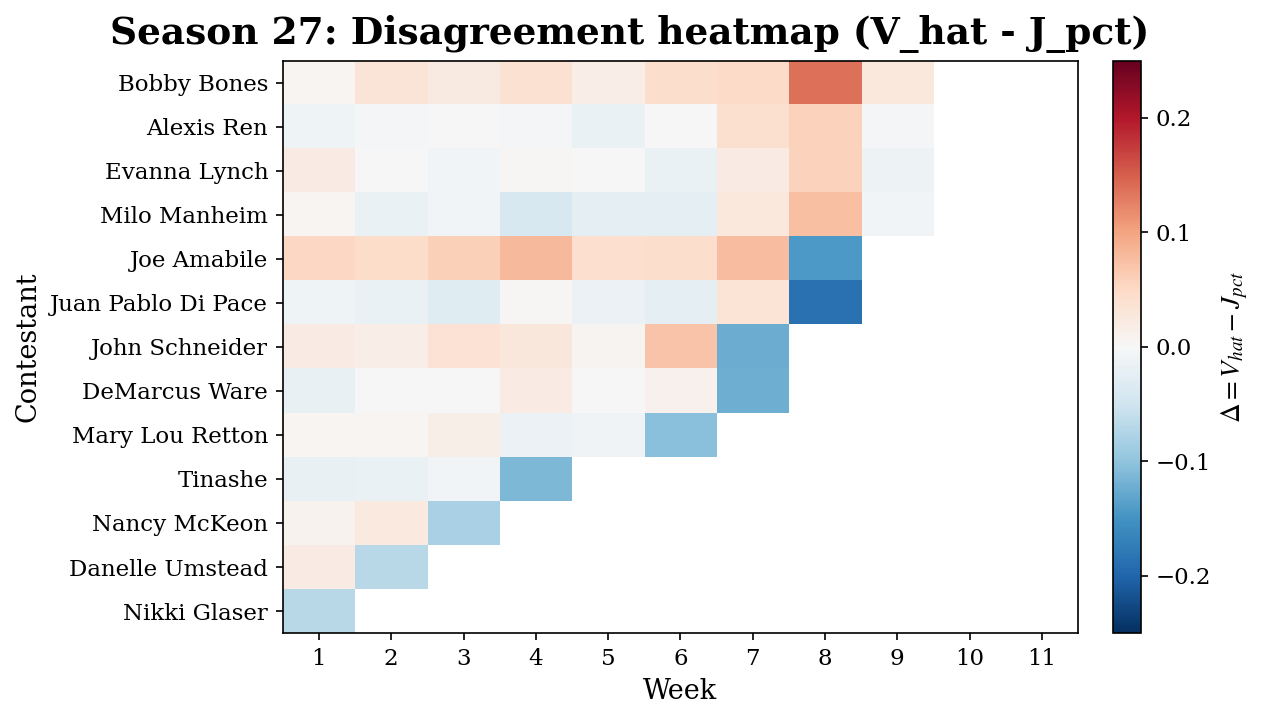

Saved figure: ../../figures/26Feb2-mcm/task2/season27_heatmap_delta_VminusJ.png


In [7]:
prefix = f"season{SEASON}"
fig_delta = os.path.join(OUTDIR, f"{prefix}_heatmap_delta_VminusJ.png")

plot_delta_heatmap(
    piv_v,
    piv_j,
    fig_delta,
    title=f"Season {SEASON}: Disagreement heatmap (V_hat - J_pct)",
    also_pdf=ALSO_PDF,
)

print("Saved figure:", fig_delta)
